# Cleaning and Customer Analysis

#### import libraries and make connection

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine

import mysql.connector

connection = mysql.connector.connect(
    host="localhost",
    user="root",
    password="Sqldata@9797",
    database="black_friday_db"
)

if connection.is_connected():
    print("Connected successfully to black_friday_db!")


Connected successfully to black_friday_db!


In [4]:
query = """select * from black_friday_data"""
df = pd.read_sql(query,connection)
df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_8140\1759975506.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query,connection)


,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00000142,F,0-17,10,A,2,0,3,4,5,13650
1,1000001,P00004842,F,0-17,10,A,2,0,3,4,12,13645
2,1000001,P00025442,F,0-17,10,A,2,0,1,2,9,15416
3,1000001,P00051442,F,0-17,10,A,2,0,8,17,Unknown,9938
4,1000001,P00051842,F,0-17,10,A,2,0,4,8,Unknown,2849


##### Never modify the original DataFrame directly.

In [5]:
df_clean = df.copy()

###### Check Categories - Age, Gender, City etc.

In [6]:
print(df_clean["Gender"].unique())

['F' 'M']


In [7]:
print(df_clean["Age"].unique())

['0-17' '55+' '26-35' '46-50' '51-55' '36-45' '18-25']


In [8]:
print(df_clean["City_Category"].unique())

['A' 'C' 'B']


In [9]:
print(df_clean["Stay_In_Current_City_Years"].unique())

['2' '4+' '3' '1' '0']


In [11]:
### Convert Categories to category:-
categorical_columns = [
    "Gender",
    "Age",
    "City_Category",
    "Stay_In_Current_City_Years"
]

for col in categorical_columns:
    df_clean[col] = df_clean[col].astype("category")

In [ ]:
### Product Category Data Types:-
### Because we used "Unknown" in SQL, these fields are strings.

### Check:

In [12]:
df_clean[
    ["Product_Category_2", "Product_Category_3"]
].dtypes

Product_Category_2    object
Product_Category_3    object
dtype: object

In [13]:
### For analysis, we'll create numeric versions too.
df_clean["Product_Category_2_Num"] = pd.to_numeric(
    df_clean["Product_Category_2"],
    errors="coerce"
)

df_clean["Product_Category_3_Num"] = pd.to_numeric(
    df_clean["Product_Category_3"],
    errors="coerce"
)

#####  Purchase Outlier Analysis

In [14]:
#### The project asks us to detect outliers in purchase behavior.
### Use the IQR method.
Q1 = df_clean["Purchase"].quantile(0.25)
Q3 = df_clean["Purchase"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

Lower Bound: -3523.5
Upper Bound: 21400.5


In [15]:
# Create a flag:
df_clean["Outlier_Flag"] = np.where(
    (df_clean["Purchase"] < lower_bound) |
    (df_clean["Purchase"] > upper_bound),
    "Outlier",
    "Normal"
)

In [16]:
# Check:
df_clean["Outlier_Flag"].value_counts()

Outlier_Flag
Normal     547391
Outlier      2677
Name: count, dtype: int64

###### important.

In [ ]:
### Don't delete the outliers automatically.
### A high-value Black Friday transaction may be completely legitimate. We'll flag them and analyze them.

#### Customer-Level Data

In [17]:
## Now we're going to create a separate customer-level DataFrame.
customer_df = (
    df_clean
    .groupby("User_ID")
    .agg(
        Total_Spend=("Purchase", "sum"),
        Transactions=("Purchase", "count"),
        Avg_Purchase=("Purchase", "mean"),
        Gender=("Gender", "first"),
        Age=("Age", "first"),
        Occupation=("Occupation", "first"),
        City_Category=("City_Category", "first"),
        Stay_Years=("Stay_In_Current_City_Years", "first"),
        Marital_Status=("Marital_Status", "first")
    )
    .reset_index()
)

In [18]:
customer_df.head()

,User_ID,Total_Spend,Transactions,Avg_Purchase,Gender,Age,Occupation,City_Category,Stay_Years,Marital_Status
0,1000001,334093,35,9545.514286,F,0-17,10,A,2,0
1,1000002,810472,77,10525.610390,M,55+,16,C,4+,0
2,1000003,341635,29,11780.517241,M,26-35,15,A,3,0
3,1000004,206468,14,14747.714286,M,46-50,7,B,2,1
4,1000005,821001,106,7745.292453,M,26-35,20,A,1,1


In [19]:
customer_df.shape

(5891, 10)

In [ ]:
### CLV Proxy
## The project defines:
## CLV = Total Purchase per User / Number of Transactions
## We'll implement exactly that:

In [20]:
customer_df["CLV_Proxy"] = (
    customer_df["Total_Spend"] /
    customer_df["Transactions"]
)

In [ ]:
## Important terminology
# We'll call it: CLV Proxy
# rather than true lifetime value because the dataset doesn't provide customer lifetime duration.

##### Category Breadth

In [28]:
## The project defines Category Breadth as the distinct product categories purchased per customer. Calculate then merge it.
category_breadth = (
    df_clean
    .groupby("User_ID")["Product_Category_1"]
    .nunique()
    .reset_index(name="Category_Breadth")
)

In [22]:
customer_df = customer_df.merge(
    category_breadth,
    on="User_ID",
    how="left"
)

In [23]:
customer_df[
    ["User_ID", "Transactions", "Category_Breadth"]
].head()

,User_ID,Transactions,Category_Breadth
0,1000001,35,11
1,1000002,77,6
2,1000003,29,6
3,1000004,14,2
4,1000005,106,12


In [24]:
### The project defines:
# City Loyalty Index = Average Purchase × Stay Years
# First convert 4+ to 4:
customer_df["Stay_Years_Num"] = (
    customer_df["Stay_Years"]
    .astype(str)
    .replace("4+", "4")
    .astype(int)
)

In [25]:
customer_df["City_Loyalty_Index"] = (
    customer_df["Avg_Purchase"] *
    customer_df["Stay_Years_Num"]
)

#####  Repeat Transaction Customer

In [27]:
# create and calculate the rate:
customer_df["Customer_Type"] = np.where(
    customer_df["Transactions"] > 1,
    "Repeat",
    "One-Time"
)

In [29]:
repeat_rate = (
    customer_df["Customer_Type"]
    .eq("Repeat")
    .mean()
    * 100
)

print(f"Repeat Transaction Customer Rate: {repeat_rate:.2f}%")

Repeat Transaction Customer Rate: 100.00%


In [ ]:
# Again, because there's no transaction date, don't call this a true retention rate.

#### Customer Segmentation

In [31]:
# Create four segment then apply and check the steps:-
spend_threshold = customer_df["Total_Spend"].quantile(0.75)
frequency_threshold = customer_df["Transactions"].quantile(0.75)

In [32]:
def segment_customer(row):

    high_spend = row["Total_Spend"] >= spend_threshold
    high_frequency = row["Transactions"] >= frequency_threshold

    if high_spend and high_frequency:
        return "High Value Loyal"

    elif high_spend:
        return "High Value"

    elif high_frequency:
        return "Frequent Buyer"

    else:
        return "Low Value"

In [33]:
customer_df["Customer_Segment"] = (
    customer_df.apply(segment_customer, axis=1)
)

In [35]:
customer_df["Customer_Segment"].value_counts()

Customer_Segment
Low Value           4307
High Value Loyal    1367
Frequent Buyer       111
High Value           106
Name: count, dtype: int64

#### EDA — Purchase Distribution
##### project specifically asks for purchase-distribution histograms:-

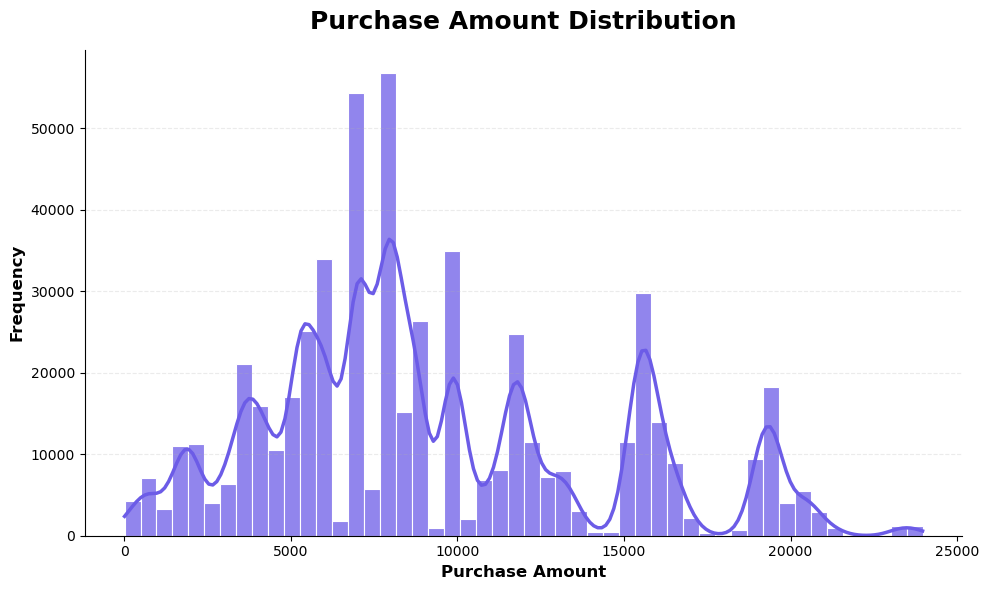

In [36]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df_clean["Purchase"],
    bins=50,
    kde=True,
    color="#6C5CE7",
    edgecolor="white",
    linewidth=0.8,
    alpha=0.75,
    line_kws={
        "color": "#E84393",
        "linewidth": 2.5
    }
)

plt.title(
    "Purchase Amount Distribution",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Purchase Amount",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Frequency",
    fontsize=12,
    fontweight="bold"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

sns.despine()

plt.tight_layout()
plt.show()

####  Boxplot — Age

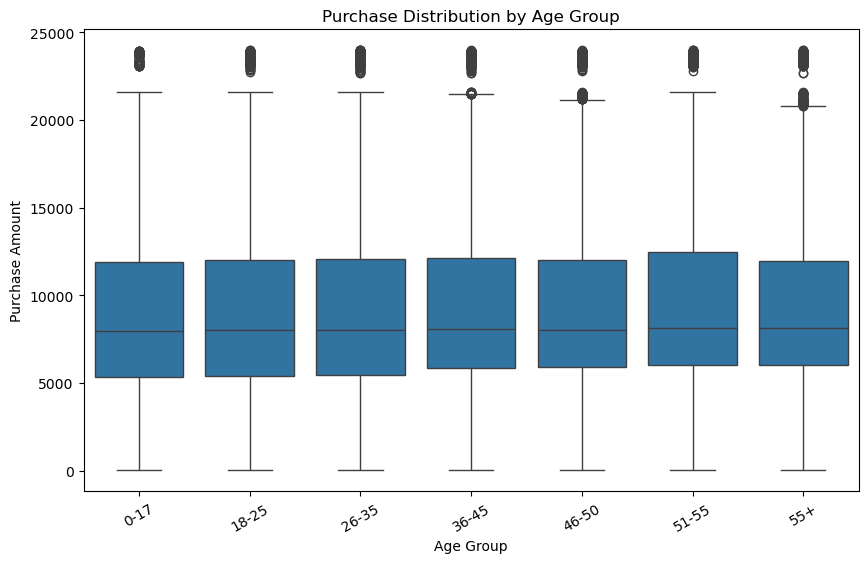

In [37]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="Age",
    y="Purchase"
)

plt.title("Purchase Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Purchase Amount")

plt.xticks(rotation=30)

plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_8140\2750780764.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


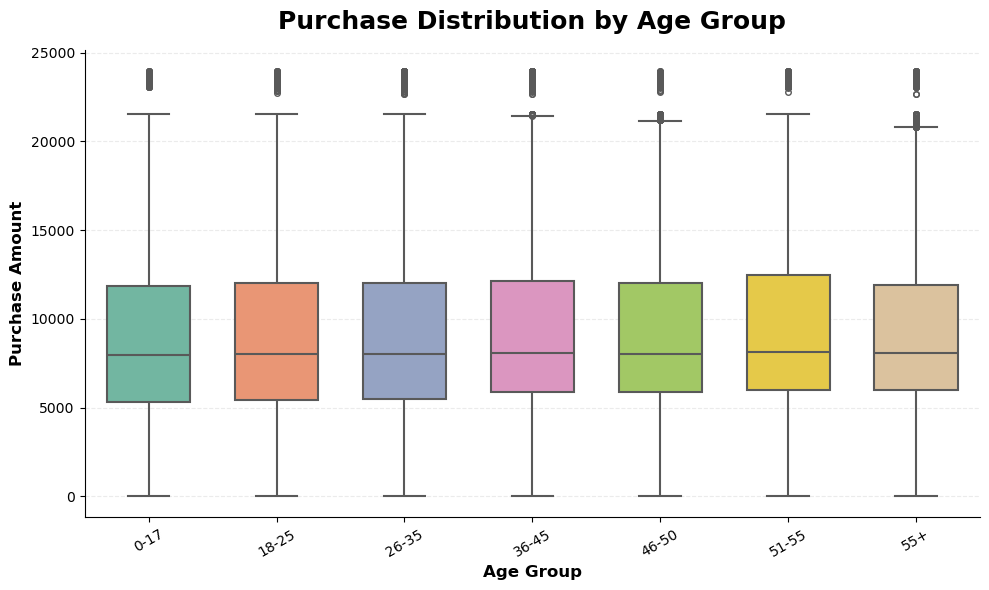

In [38]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df_clean,
    x="Age",
    y="Purchase",
    palette="Set2",
    width=0.65,
    linewidth=1.5,
    fliersize=4
)

plt.title(
    "Purchase Distribution by Age Group",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Age Group",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Purchase Amount",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=30,
    fontsize=10
)

plt.yticks(fontsize=10)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

sns.despine()

plt.tight_layout()
plt.show()

#### Boxplot — City

C:\Users\user\AppData\Local\Temp\ipykernel_8140\3914374153.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


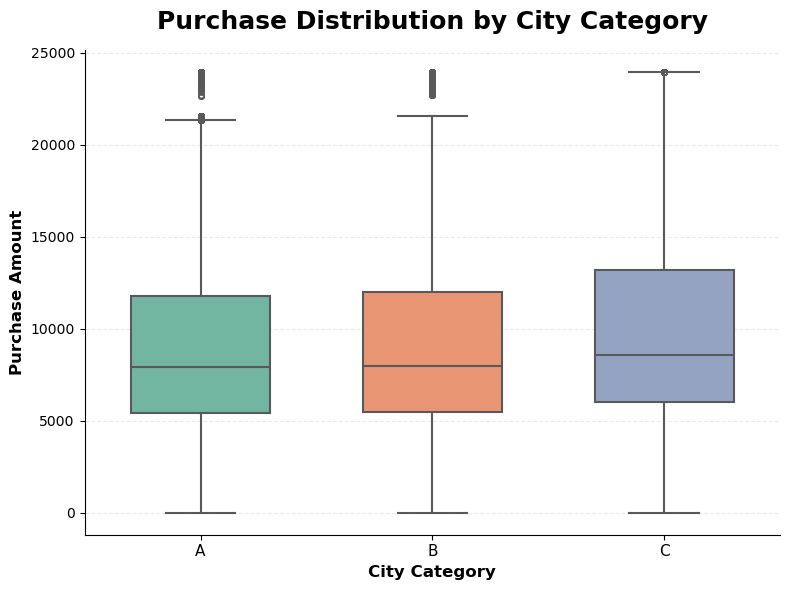

In [39]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df_clean,
    x="City_Category",
    y="Purchase",
    palette="Set2",
    width=0.6,
    linewidth=1.5,
    fliersize=4
)

plt.title(
    "Purchase Distribution by City Category",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "City Category",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Purchase Amount",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=10)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

sns.despine()

plt.tight_layout()
plt.show()

#### Boxplot — Marital Status

C:\Users\user\AppData\Local\Temp\ipykernel_8140\3677669614.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


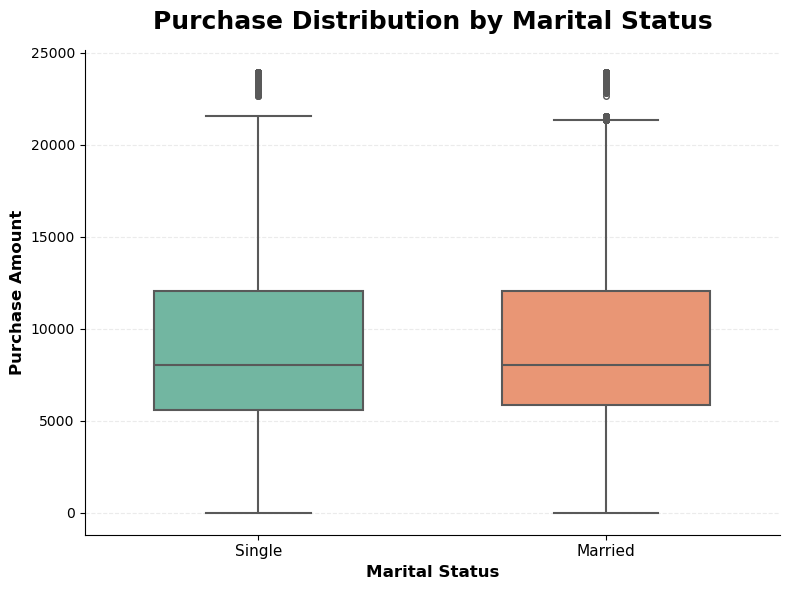

In [40]:
df_clean["Marital_Status_Label"] = (
    df_clean["Marital_Status"]
    .map({
        0: "Single",
        1: "Married"
    })
)
plt.figure(figsize=(8, 6))

sns.boxplot(
    data=df_clean,
    x="Marital_Status_Label",
    y="Purchase",
    palette="Set2",
    width=0.6,
    linewidth=1.5,
    fliersize=4
)

plt.title(
    "Purchase Distribution by Marital Status",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Marital Status",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Purchase Amount",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(fontsize=11)
plt.yticks(fontsize=10)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

sns.despine()

plt.tight_layout()
plt.show()

#### Sales by Product Category

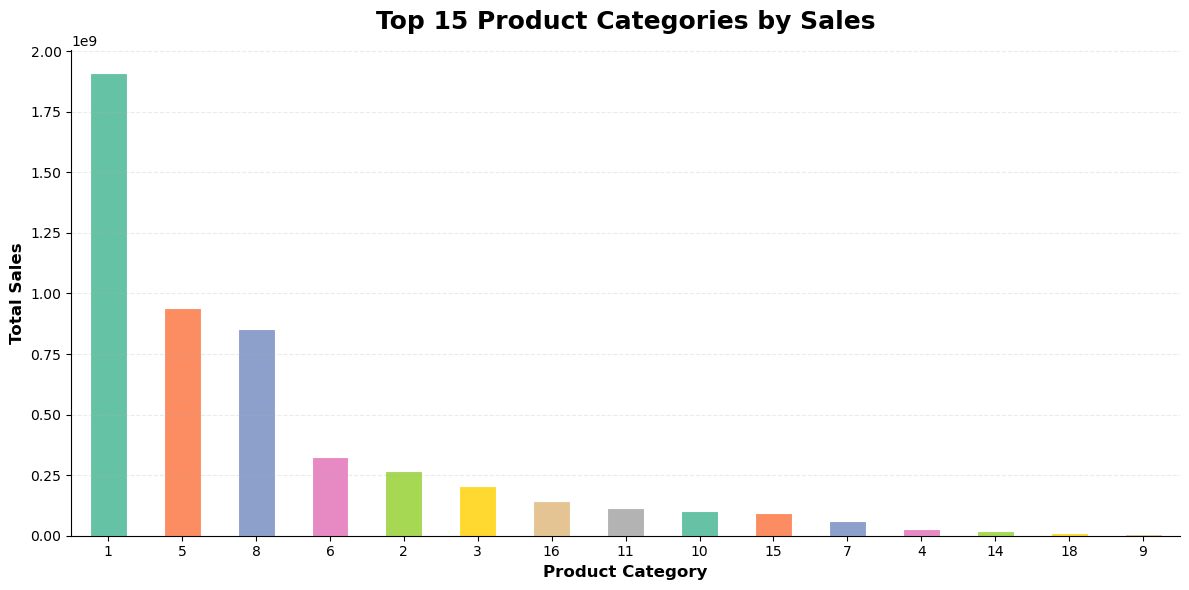

In [41]:
category_sales = (
    df_clean
    .groupby("Product_Category_1", observed=True)["Purchase"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

category_sales.head(15).plot(
    kind="bar",
    color=sns.color_palette("Set2", 15),
    edgecolor="white",
    linewidth=0.8
)

plt.title(
    "Top 15 Product Categories by Sales",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Product Category",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Total Sales",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=0,
    fontsize=10
)

plt.yticks(fontsize=10)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

sns.despine()

plt.tight_layout()
plt.show()

#### Sales by Age

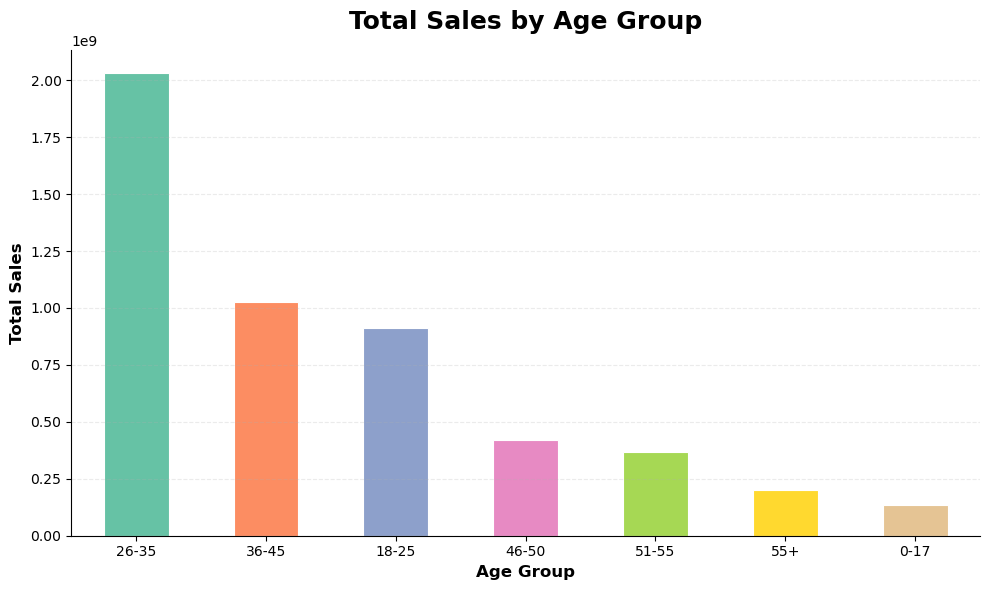

In [42]:
age_sales = (
    df_clean
    .groupby("Age", observed=True)["Purchase"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

age_sales.plot(
    kind="bar",
    color=sns.color_palette("Set2", len(age_sales)),
    edgecolor="white",
    linewidth=0.8
)

plt.title(
    "Total Sales by Age Group",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "Age Group",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Total Sales",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=0,
    fontsize=10
)

plt.yticks(fontsize=10)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

sns.despine()

plt.tight_layout()
plt.show()

#### Sales by City

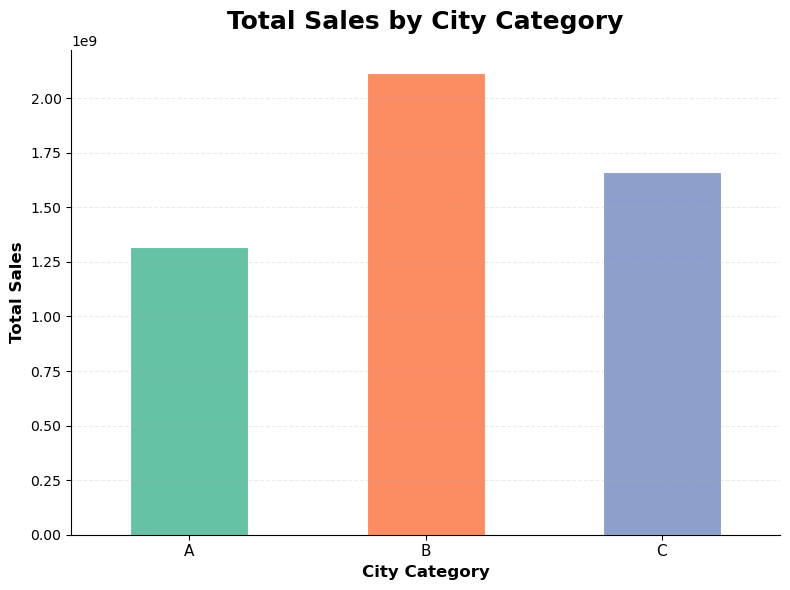

In [43]:
city_sales = (
    df_clean
    .groupby("City_Category", observed=True)["Purchase"]
    .sum()
)

plt.figure(figsize=(8, 6))

city_sales.plot(
    kind="bar",
    color=sns.color_palette("Set2", len(city_sales)),
    edgecolor="white",
    linewidth=0.8
)

plt.title(
    "Total Sales by City Category",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xlabel(
    "City Category",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Total Sales",
    fontsize=12,
    fontweight="bold"
)

plt.xticks(
    rotation=0,
    fontsize=11
)

plt.yticks(fontsize=10)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

sns.despine()

plt.tight_layout()
plt.show()

#### Correlation Heatmap
##### The capstone specifically asks for heatmaps to study relationships involving demographics and purchase amounts.

##### We'll be careful here because fields such as Occupation and product category IDs are codes, not naturally continuous variables.

##### Start with genuinely numeric customer-level measures:

In [44]:
corr_cols = [
    "Total_Spend",
    "Transactions",
    "Avg_Purchase",
    "CLV_Proxy",
    "Category_Breadth",
    "Stay_Years_Num",
    "City_Loyalty_Index"
]

corr = customer_df[corr_cols].corr()

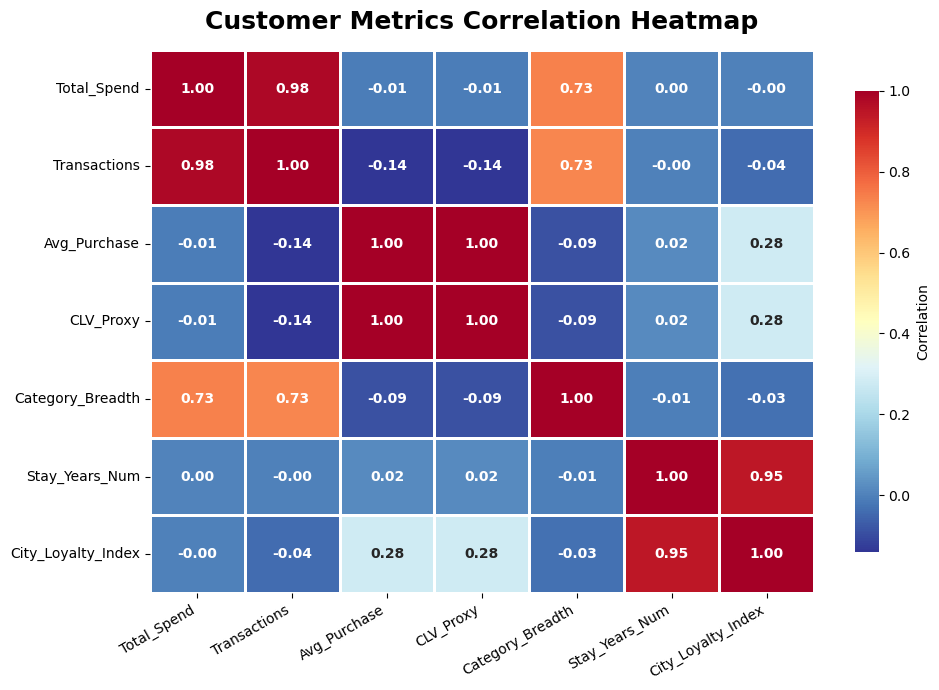

In [45]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    linewidths=1,
    linecolor="white",
    annot_kws={
        "fontsize": 10,
        "fontweight": "bold"
    },
    cbar_kws={
        "shrink": 0.85,
        "label": "Correlation"
    }
)

plt.title(
    "Customer Metrics Correlation Heatmap",
    fontsize=18,
    fontweight="bold",
    pad=15
)

plt.xticks(
    fontsize=10,
    rotation=30,
    ha="right"
)

plt.yticks(
    fontsize=10,
    rotation=0
)

plt.tight_layout()
plt.show()

## Save Cleaned Data

In [46]:
df_clean.to_csv(
    "black_friday_cleaned.csv",
    index=False
)

In [47]:
customer_df.to_csv(
    "customer_analysis.csv",
    index=False
)
